# Çapraz Hedef: Kuyruk Teorisi Stok Seviyesi — `target_capraz_kuyruk_stok_seviyesi` (AutoGluon TimeSeries)

Bu defter, piyasada o an aktif olarak satılık olduğu tahmin edilen araç **stok seviyesini**
(adet) bir ay ilerisi için tahmin eden rolling-origin backtest çalışmasını uçtan uca üretir ve
doğrular.

Diğer iki hedeften (`target_betam_dom_gun`: ham kolonun birebir kopyası; `target_quickfinans_dom_gun`:
tamamen harici bir dosyadan okunur) farklı, ama `target_capraz_ikinciel_yeniarac_satis_orani` ile
aynı ailede: `hiz_target_backtest_pipeline.py` içindeki `DERIVED_TARGET_FORMULAS` sözlüğü — harici
hiçbir kaynağa ihtiyaç duymadan, **`feature_master_aylik.csv` içinde zaten var olan iki ham
kolonun matematiksel birleşimi** olarak anında ("çapraz") hesaplanır. Oran hedefinden farkı: bu
kez tek bir bölme değil, **Little's Law** (kuyruk teorisi, `L = λ·W`) uygulanan iki adımlı bir
dönüşüm var:

\[
\text{target\_capraz\_kuyruk\_stok\_seviyesi}_t =
\underbrace{\frac{\text{noter\_devir\_otomobil\_adet}_t}{\text{o ayın gün sayısı}}}_{\lambda_t \;(\text{günlük devir akışı})}
\times
\underbrace{\text{betam\_dom\_gun}_t}_{W_t \;(\text{ortalama ilanda kalış süresi, gün})}
\]

- `noter_devir_otomobil_adet`: o ay noterde el değiştiren otomobil (ikinci el devir) adedi —
  ay uzunluğu farkını (28-31 gün) gidermek için önce **günlük akışa** (`λ`) çevrilir.
- `betam_dom_gun`: BETAM raporundaki ortalama ilanda kalış süresi (gün) — kuyruk teorisindeki
  ortalama **bekleme/hizmet süresi** (`W`) rolünde.
- Little's Law (`L = λ·W`), bir kuyruktaki (burada: "satışa çıkmış ama henüz satılmamış araç
  havuzu") ortalama **eleman sayısını**, akış hızı ile o akıştaki ortalama kalış süresinin
  çarpımı olarak verir. Burada `L_t`, referans ayında piyasada aktif olduğu tahmin edilen
  satılık araç **SEVİYESİ** (stok adedi) — bir **büyüme hızı değil**.

> **Tasarım notu — neden büyüme hızı değil seviye?** Bu hedef bilinçli olarak seviye (level)
> olarak tanımlandı. Büyüme-hızı versiyonu (`log(L_t) - log(L_{t-1})`), `log(λ·W) = log(λ) + log(W)`
> özdeşliği gereği, projede zaten var olan iki hedefin — `target_1ay_hiz` (noter devrinin aylık
> büyüme hızı) ile `betam_dom_gun`'un log-farkının — cebirsel toplamına eşit çıktığı adversarial
> doğrulamada tespit edildi (fark < 1e-13): yani gerçek bir yeni etkileşim sinyali taşımıyor,
> matematiksel olarak zaten var olan iki hedefin toplamından ibaret. Seviye versiyonu ise gerçekten
> yeni bir büyüklüğü (stok adedi) ifade ettiği için modelleme açısından anlamlı.

Formülün her iki kaynak kolonu da (`noter_devir_otomobil_adet`, `betam_dom_gun`) kendi-kaynak
sızıntı riski taşıdığından feature listesinden birlikte dışlanır (bkz. Bölüm 2).

- Veri: 28 gözlem, 2024-01 → 2026-06
- AutoGluon ayarı: `medium_quality`, fold başına `time_limit=45sn`
- Tahmin ufku: 1 ay (`prediction_length=1`)
- Backtest: son 6 ay (2025-12, 2026-01, 2026-03, 2026-04, 2026-05, 2026-06; 2026-02 sıçraması
  hakkında bkz. Bölüm 5) — rolling-origin / genişleyen pencere — her test ayı yalnız kendinden
  önceki gerçek verilerle sıfırdan eğitilen ayrı bir modelle tahmin edilir
- Referans: "geçen yılın aynı ayı" (t-12) naive baseline

## 1. Kütüphaneler ve sabitler

Bu notebook proje kökünden veya `notebooks/` klasöründen açılabilir; `.venv-ag` ortamını gerektirir.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FEATURE_PATH = ROOT / "data" / "target_bazli_birlesik_setler" / "feature_master_aylik.csv"
OUT_DIR = ROOT / "outputs" / "hiz_target_backtest" / "target_capraz_kuyruk_stok_seviyesi"

TARGET = "target_capraz_kuyruk_stok_seviyesi"
DATE_COL = "referans_ayi"
KAYNAK_KOLONLAR = ["betam_dom_gun", "noter_devir_otomobil_adet"]

print("Proje kökü:", ROOT)
print("Hedef:", TARGET)

Proje kökü: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2
Hedef: target_capraz_kuyruk_stok_seviyesi


## 2. Sızıntısız feature tablosu kurma — iki kaynak kolonun birlikte dışlanması

`feature_master_aylik.csv`'deki tüm aylık feature'lar hedefe eklenir. `target_capraz_kuyruk_stok_seviyesi`,
`DERIVED_TARGET_FORMULAS` mekanizmasıyla üretilen bir "çapraz" (türetilmiş) hedeftir: ne
`target_quickfinans_dom_gun` gibi harici bir dosyadan okunur, ne de `target_betam_dom_gun` gibi
`feature_master_aylik.csv`'de zaten hazır duran tek bir ham kolonun birebir kopyasıdır — bunun
yerine, dosyada zaten var olan **iki** ham kolonun (`noter_devir_otomobil_adet`, `betam_dom_gun`)
Little's Law ile birleşimi olarak anında hesaplanır. `TARGET_TO_SOURCE_COL` (kolon → tek isim)
yerine `DERIVED_TARGET_FORMULAS` sözlüğü kullanılır; bu hedefin girdisinin `kaynak_kolonlar`
alanı yine bir **küme** (iki eleman) tutar — formül tek bir oran değil, "böl + çarp" işlemi olsa
da sızıntı kaynağı sayılan ham kolon sayısı aynı şekilde ikidir. Üç tür kolon dışlanır:

1. **Hedefin türetildiği HER İKİ ham kaynak kolon** (`noter_devir_otomobil_adet` VE
   `betam_dom_gun`) — hedef bu iki kolonun matematiksel bir fonksiyonu olduğundan, ikisinden
   biri feature olarak kalsaydı dolaylı/doğrudan kopya sızıntısı olurdu.
2. **Genel sızıntı yasakları** (`modelleme_sizinti_kisitlari.csv`'nin `tum_targetlar` satırları):
   karışık aylık/yıllık reel değişim kolonu, ÖTV-en-yakın-olay farkı, audit kolonu.
3. **`indicata_*`/`arabam_*`/`betam_*` ailesinin aynı-ay versiyonları** — bu raporlar referans
   ayından sonra yayımlanıyor; bunun yerine 1 ay gecikmeli (`lag1`) türevleri kullanılır (bu
   ailenin bir üyesi olan `betam_dom_gun`'un kendisi zaten madde 1 kapsamında tamamen dışlandığı
   için, burada yalnızca `betam_dom_gun_lag1` gibi diğer `betam_*`/`indicata_*`/`arabam_*` aile
   üyeleri gecikmeli haliyle feature listesinde kalır).

`build_feature_table`, `target_col` bir `DERIVED_TARGET_FORMULAS` anahtarıysa ilgili `func`'ı
(`_formul_kuyruk_stok_seviyesi`) uygulayarak hedefi `feature_master_aylik.csv`'den türetir ve
`kaynak_kolonlar` kümesinin tamamını `excluded_self`'e ekler — aşağıdaki iki fonksiyon kodunda
görülebilir.

In [2]:
def _formul_kuyruk_stok_seviyesi(fm: pd.DataFrame) -> pd.Series:
    # Little's Law (L = lambda * W): lambda gunluk akisa cevrilir (ay uzunlugu 28-31 gun
    # farkini gidermek icin), W = betam_dom_gun (gun). L_t = o an piyasada aktif tahmini
    # satilik arac sayisi. Buyume-hizi DEGIL, SEVIYE olarak tanimlanir - adversarial
    # dogrulamada buyume-hizi versiyonunun log(A*B)=log(A)+log(B) ozdesligi geregi
    # target_1ay_hiz + betam_dom_gun log-farkina cebirsel olarak esit ciktigi (fark<1e-13),
    # yani gercek bir etkilesim degil iki mevcut targetin toplami oldugu tespit edildi.
    gun_sayisi = pd.to_datetime(fm["referans_ayi"]).dt.days_in_month
    return (fm["noter_devir_otomobil_adet"] / gun_sayisi) * fm["betam_dom_gun"]

def build_feature_table(target_col: str) -> tuple[pd.DataFrame, list[str], dict]:
    fm = pd.read_csv(FEATURE_PATH)

    if target_col in DERIVED_TARGET_FORMULAS:
        # Hedef, feature_master_aylik.csv'deki VAR OLAN ham kolonlarin matematiksel
        # capraz-referanslanmasiyla (oran/fark/carpim) turetilir - hicbir harici kaynak
        # veya master veri seti gerekmez.
        spec = DERIVED_TARGET_FORMULAS[target_col]
        target_series = spec["func"](fm)
        mv = pd.DataFrame({DATE_COL: fm[DATE_COL], target_col: target_series})
    elif target_col in EXTERNAL_TARGET_SOURCES:
        # Bu hedefin ham kaynagi feature_master_aylik.csv / master veri setinde YOK -
        # ayri bir data/ klasorunden okunup referans_ayi uzerinden birlestirilir.
        src = EXTERNAL_TARGET_SOURCES[target_col]
        ext = pd.read_csv(src["csv"])[[src["date_col"], src["value_col"]]]
        ext = ext.rename(columns={src["date_col"]: DATE_COL, src["value_col"]: target_col})
        mv = ext
    else:
        mv = pd.read_csv(MASTER_PATH)[[DATE_COL, target_col]]

    df = fm.merge(mv, on=DATE_COL, how="left")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    if target_col in DERIVED_TARGET_FORMULAS:
        excluded_self = set(DERIVED_TARGET_FORMULAS[target_col]["kaynak_kolonlar"])
    else:
        source_col = TARGET_TO_SOURCE_COL.get(target_col)
        excluded_self = {source_col} if source_col else set()
    excluded_hard = HARD_EXCLUDE_ALWAYS & set(df.columns)

    lagged_created = []
    raw_family_cols = [
        c for c in fm.columns
        if c != DATE_COL and c.startswith(LAGGED_FAMILY_PREFIXES) and c not in excluded_hard
    ]
    for col in raw_family_cols:
        lag_col = f"{col}_lag1"
        df[lag_col] = df[col].shift(1)
        lagged_created.append(lag_col)

    df["ay"] = df[DATE_COL].dt.month
    df["ceyrek"] = df[DATE_COL].dt.quarter
    df["sin_ay"] = np.sin(2 * np.pi * df["ay"] / 12.0)
    df["cos_ay"] = np.cos(2 * np.pi * df["ay"] / 12.0)
    calendar_cols = ["ay", "ceyrek", "sin_ay", "cos_ay"]

    drop_cols = excluded_self | excluded_hard | set(raw_family_cols)
    candidate_features = [
        c for c in df.columns
        if c not in drop_cols and c not in (DATE_COL, target_col) and c not in lagged_created
    ] + lagged_created + calendar_cols
    candidate_features = list(dict.fromkeys(candidate_features))  # sirali unique

    exclusion_log = {
        "hedefin_ham_kaynak_kolonu_disi": sorted(excluded_self),
        "genel_sizinti_yasaklari": sorted(excluded_hard),
        "ayni_ay_yerine_lag1_yapilan_aile_kolonlari": sorted(raw_family_cols),
    }
    return df, candidate_features, exclusion_log

## 3. Korelasyon filtresi — |Pearson| < 0.1 ele

`min_periods=12` (en az 12 örtüşen gözlem) şartıyla hedefle mutlak korelasyonu 0.1 altında olan
veya hesaplanamayan (NaN) feature'lar elenir.

In [3]:
def korelasyon_filtresi(df: pd.DataFrame, target_col: str, features: list[str]) -> tuple[list[str], pd.DataFrame]:
    sub = df.dropna(subset=[target_col])
    corr = sub[features + [target_col]].corr(min_periods=MIN_PERIODS)[target_col].drop(target_col)
    ozet = pd.DataFrame({
        "feature": corr.index,
        "korelasyon": corr.values,
        "karar": np.where(corr.abs() >= CORR_ESIK, "tutuldu", "elendi"),
    }).sort_values("korelasyon")
    tutulan = ozet.loc[ozet["karar"] == "tutuldu", "feature"].tolist()
    return tutulan, ozet

## 4. Çoklu-doğrusallık filtresi — |Pearson| > 0.9 ele

Kalan feature'lar arasında mutlak korelasyonu 0.9'u aşan çiftlerden target ile daha düşük
korelasyona sahip olan, union-find ile bulunan bağlı bileşen grupları üzerinden elenir.

In [4]:
def coklu_dogrusallik_azalt(df: pd.DataFrame, target_col: str, features: list[str]) -> tuple[list[str], pd.DataFrame]:
    sub = df.dropna(subset=[target_col])
    if len(features) < 2:
        return features, pd.DataFrame(columns=["feature_a", "feature_b", "korelasyon", "elenen"])

    hedef_korr = sub[features + [target_col]].corr(min_periods=MIN_PERIODS)[target_col].drop(target_col)
    feat_korr = sub[features].corr(min_periods=MIN_PERIODS)

    ebeveyn = {f: f for f in features}

    def bul(f):
        while ebeveyn[f] != f:
            f = ebeveyn[f]
        return f

    def birlestir(a, b):
        ra, rb = bul(a), bul(b)
        if ra != rb:
            ebeveyn[ra] = rb

    pair_rows = []
    for i, a in enumerate(features):
        for b in features[i + 1:]:
            v = feat_korr.loc[a, b]
            if pd.notna(v) and abs(v) > COLLIN_ESIK:
                birlestir(a, b)
                pair_rows.append({"feature_a": a, "feature_b": b, "korelasyon": v})

    gruplar: dict[str, list[str]] = {}
    for f in features:
        gruplar.setdefault(bul(f), []).append(f)

    tutulan = list(features)
    elenen_set = set()
    for grup in gruplar.values():
        if len(grup) < 2:
            continue
        skorlu = [(f, abs(hedef_korr.get(f, np.nan))) for f in grup]
        skorlu = [(f, s if pd.notna(s) else -1.0) for f, s in skorlu]
        en_iyi = max(skorlu, key=lambda x: x[1])[0]
        for f in grup:
            if f != en_iyi:
                elenen_set.add(f)
                tutulan.remove(f)

    pair_df = pd.DataFrame(pair_rows)
    if not pair_df.empty:
        pair_df["elenen"] = pair_df.apply(
            lambda r: r["feature_a"] if r["feature_a"] in elenen_set else (r["feature_b"] if r["feature_b"] in elenen_set else ""),
            axis=1,
        )
    return tutulan, pair_df

## 5. Rolling-origin backtest ayları ve tek-adım eğitim/tahmin

Bir ay `m` geçerli bir backtest ayı sayılır ancak (a) `m-12` de hedefte mevcutsa (baseline için
gerekli) ve (b) `m`'den önce en az `MIN_TRAIN_AY=8` ay eğitim verisi varsa. Son 6 geçerli ay
seçilir. Her fold'da eğitim verisi hedefin **ilk gerçek gözleminden** başlar — aksi halde
`ffill().bfill()`, hedefin başlamadığı erken yılları ilk gerçek değerle geriye doldurup uydurma
bir geçmiş yaratırdı (bu proje bir kullanıcı sorusuyla yakalanıp düzeltilmiş bir hatadır).

Not: bu hedefte 6 backtest ayı **ardışık değil** — liste `2025-12, 2026-01, 2026-03, 2026-04,
2026-05, 2026-06` şeklinde, 2026-02 aralıkta yok. Bunun nedeni `find_backtest_months`'ın (a)
şartı: 2026-02'nin geçerli olması için 2025-02'nin de hedefte mevcut olması gerekir, ama seride
2025-02 iç boşluk (eksik gözlem) olduğundan 2026-02 aday listesine hiç girmiyor ve en yakın 6
geçerli ay (2026-02 hariç) seçiliyor.

In [5]:
def find_backtest_months(df: pd.DataFrame, target_col: str) -> list[pd.Timestamp]:
    valid = df.dropna(subset=[target_col])[[DATE_COL, target_col]].copy()
    valid = valid.set_index(DATE_COL)[target_col]
    aday_aylar = []
    for m in valid.index:
        t_minus_12 = m - pd.DateOffset(months=12)
        if t_minus_12 in valid.index:
            train_count = (valid.index < m).sum()
            if train_count >= MIN_TRAIN_AY:
                aday_aylar.append(m)
    return sorted(aday_aylar)[-MAX_BACKTEST_AY:]

def prev_actual_value(valid_series: pd.Series, origin_month: pd.Timestamp):
    onceki = valid_series[valid_series.index <= origin_month]
    if onceki.empty:
        return np.nan
    return onceki.iloc[-1]

def fit_predict_one_step(train_df: pd.DataFrame, target_col: str, features: list[str], forecast_month: pd.Timestamp, model_dir: Path):
    keep_cols = [DATE_COL, target_col, *features]
    clean = train_df[keep_cols].copy()
    clean = clean.sort_values(DATE_COL)
    clean = clean.ffill().bfill()
    clean["item_id"] = "TR_otomobil"

    ts_df = TimeSeriesDataFrame.from_data_frame(clean, id_column="item_id", timestamp_column=DATE_COL)

    if model_dir.exists():
        import shutil
        shutil.rmtree(model_dir, ignore_errors=True)

    predictor = TimeSeriesPredictor(
        target=target_col,
        prediction_length=1,
        eval_metric="MAE",
        freq="MS",
        path=str(model_dir),
        verbosity=0,
    )
    predictor.fit(train_data=ts_df, presets="medium_quality", time_limit=FIT_TIME_LIMIT)
    pred = predictor.predict(ts_df)
    pred_df = pred.loc["TR_otomobil"].reset_index()
    pred_df["timestamp"] = pd.to_datetime(pred_df["timestamp"])
    row = pred_df.loc[pred_df["timestamp"] == forecast_month]
    if row.empty:
        return np.nan, predictor.model_best
    return float(row["mean"].iloc[0]), predictor.model_best

## 6. Metrikler — yön doğruluğu, MAE, RMSE, MASE, sMAPE, bias

- **Yön doğruluğu**: tahmin edilen değişimin yönü (bir önceki bilinen gerçek değere göre), gerçekleşen
  yönle eşleşme oranı.
- **MASE**: MAE'nin, tüm geçmişteki ortalama mutlak 12-aylık (mevsimsel) farka bölünmüş hali; `<1`
  serinin kendi mevsimsel oynaklığından daha iyi demektir.
- **sMAPE**: ölçekten bağımsız yüzdesel hata; farklı birimdeki hedefleri karşılaştırmaya yarar.
- **Bias**: `ortalama(tahmin - gerçek)`; pozitifse model sistematik olarak yüksek, negatifse düşük tahmin eder.

In [6]:
def compute_metrics(actual: np.ndarray, pred: np.ndarray, prev_actual: np.ndarray, mase_scale: float) -> dict:
    err = pred - actual
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    mase = float(mae / mase_scale) if mase_scale and mase_scale > 0 else float("nan")
    # sMAPE: olcekten bagimsiz, yuzdesel hata - farkli birimdeki hedefleri karsilastirmaya
    # yarar. |actual|+|pred|=0 olan (ikisi de tam sifir) noktalar disariya birakilir.
    smape_payda = np.abs(actual) + np.abs(pred)
    smape_gecerli = smape_payda > 0
    if smape_gecerli.sum() > 0:
        smape = float(np.mean(200 * np.abs(err[smape_gecerli]) / smape_payda[smape_gecerli]))
    else:
        smape = float("nan")

    gercek_yon = np.sign(actual - prev_actual)
    tahmin_yon = np.sign(pred - prev_actual)
    gecerli = gercek_yon != 0
    if gecerli.sum() > 0:
        yon_dogrulugu = float(np.mean(tahmin_yon[gecerli] == gercek_yon[gecerli]))
    else:
        yon_dogrulugu = float("nan")

    return {
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "mase": mase,
        "smape_pct": smape,
        "yon_dogrulugu": yon_dogrulugu,
        "n_test_ay": int(len(actual)),
    }

## 7. Uçtan uca çalıştırma fonksiyonu

`run()` yukarıdaki tüm adımları sırayla uygular, her fold için AutoGluon'u eğitir/tahmin eder,
model ile "geçen yılın aynı ayı" baseline'ını aynı 6 metrikle karşılaştırır ve çıktıları
`outputs/hiz_target_backtest/target_capraz_kuyruk_stok_seviyesi/` altına yazar.

In [7]:
def run(target_col: str) -> dict:
    out_dir = OUT_ROOT / target_col
    out_dir.mkdir(parents=True, exist_ok=True)
    model_dir_base = out_dir / "ag_models"

    df, candidate_features, exclusion_log = build_feature_table(target_col)
    tutulan_corr, corr_ozet = korelasyon_filtresi(df, target_col, candidate_features)
    corr_ozet.to_csv(out_dir / "korelasyon_filtre_ozeti.csv", index=False, encoding="utf-8-sig")

    tutulan_final, pair_df = coklu_dogrusallik_azalt(df, target_col, tutulan_corr)
    pair_df.to_csv(out_dir / "coklu_dogrusallik_ciftleri.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame({"feature": tutulan_final}).to_csv(out_dir / "final_feature_seti.csv", index=False, encoding="utf-8-sig")

    valid_series = df.dropna(subset=[target_col]).set_index(DATE_COL)[target_col]
    n_obs = len(valid_series)
    tarih_min = valid_series.index.min()
    tarih_max = valid_series.index.max()

    result = {
        "target": target_col,
        "n_obs_toplam": int(n_obs),
        "tarih_araligi": f"{tarih_min.strftime('%Y-%m') if pd.notna(tarih_min) else None} -> {tarih_max.strftime('%Y-%m') if pd.notna(tarih_max) else None}",
        "aday_feature_sayisi": len(candidate_features),
        "korelasyon_sonrasi_feature_sayisi": len(tutulan_corr),
        "final_feature_sayisi": len(tutulan_final),
        "final_feature_listesi": tutulan_final,
        "disislanan_kolonlar": exclusion_log,
    }

    backtest_months = find_backtest_months(df, target_col)
    result["backtest_ay_sayisi"] = len(backtest_months)
    result["backtest_aylari"] = [m.strftime("%Y-%m") for m in backtest_months]

    if len(tutulan_corr) == 0:
        result["durum"] = "VERI_YETERSIZ_KORELASYON_HESAPLANAMADI"
        result["not"] = (
            f"Bu hedef icin yalnizca {n_obs} gozlem var; min_periods={MIN_PERIODS} esigi "
            f"nedeniyle hicbir feature icin guvenilir korelasyon hesaplanamadi (tum degerler NaN). "
            f"Bu hedef mevcut veriyle modellenemez durumda."
        )
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    if len(backtest_months) == 0:
        result["durum"] = "VERI_YETERSIZ_BACKTEST_YOK"
        result["not"] = (
            f"Bu hedef icin {n_obs} gozlem mevcut ({result['tarih_araligi']}), ancak serinin "
            f"tamami tek bir takvim yili icinde oldugundan (veya yeterli t-12 karsiligi bulunmadigindan) "
            f"'gecen yilin ayni ayi' referans karsilastirmasi ve rolling backtest yapilamiyor."
        )
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    # MASE olcek paydasi: tum gecmis (t, t-12) ciftleri uzerinden ortalama mutlak mevsimsel fark
    tum_farklar = []
    for m in valid_series.index:
        t12 = m - pd.DateOffset(months=12)
        if t12 in valid_series.index:
            tum_farklar.append(abs(valid_series[m] - valid_series[t12]))
    mase_scale = float(np.mean(tum_farklar)) if tum_farklar else float("nan")
    result["mase_olcek_payda_ortalama_mutlak_mevsimsel_fark"] = mase_scale

    kayitlar = []
    for m in backtest_months:
        origin = m - pd.DateOffset(months=1)
        # Hedefin ilk gercek gozleminden ONCEKI satirlari kirp: aksi halde asagidaki
        # ffill/bfill, hedefin baslamadigi yillari ilk gercek degerle geriye doldurup
        # uydurma duz bir gecmis yaratir (bu bug bir kullanici sorusuyla yakalandi).
        train_df = df[(df[DATE_COL] <= origin) & (df[DATE_COL] >= tarih_min)]
        model_dir = model_dir_base / m.strftime("%Y%m")
        try:
            forecast, best_model = fit_predict_one_step(train_df, target_col, tutulan_final, m, model_dir)
        except Exception as e:
            print(f"[HATA] {target_col} {m.strftime('%Y-%m')} fit/predict basarisiz: {e}", file=sys.stderr)
            continue

        actual = float(valid_series.get(m, np.nan))
        t12 = m - pd.DateOffset(months=12)
        baseline = float(valid_series.get(t12, np.nan))
        prev_a = prev_actual_value(valid_series, origin)

        kayitlar.append({
            "ay": m.strftime("%Y-%m"),
            "gercek": actual,
            "model_tahmin": forecast,
            "baseline_gecen_yil_ayni_ay": baseline,
            "onceki_bilinen_gercek": prev_a,
            "en_iyi_model": best_model,
        })

    backtest_df = pd.DataFrame(kayitlar)
    backtest_df.to_csv(out_dir / "backtest_sonuclari.csv", index=False, encoding="utf-8-sig")

    if backtest_df.empty:
        result["durum"] = "MODEL_EGITIMI_BASARISIZ"
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    actual_arr = backtest_df["gercek"].values
    model_arr = backtest_df["model_tahmin"].values
    baseline_arr = backtest_df["baseline_gecen_yil_ayni_ay"].values
    prev_arr = backtest_df["onceki_bilinen_gercek"].values

    model_metrikleri = compute_metrics(actual_arr, model_arr, prev_arr, mase_scale)
    baseline_metrikleri = compute_metrics(actual_arr, baseline_arr, prev_arr, mase_scale)

    result["durum"] = "TAMAMLANDI"
    result["model_metrikleri"] = model_metrikleri
    result["baseline_metrikleri_gecen_yil_ayni_ay"] = baseline_metrikleri
    result["en_iyi_modeller_fold_bazinda"] = backtest_df["en_iyi_model"].tolist()

    (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

    # --- Grafik ---
    plt.figure(figsize=(11, 5.5))
    history_len = min(24, len(valid_series))
    hist = valid_series.iloc[-history_len:]
    plt.plot(hist.index, hist.values, label="Gercek (tum tarihce)", color="#1f77b4", linewidth=2, marker="o", markersize=4)
    bt_dates = pd.to_datetime(backtest_df["ay"])
    plt.plot(bt_dates, backtest_df["model_tahmin"], label="AutoGluon Tahmini (backtest, h=1)", color="#d62728", linestyle="--", marker="s", linewidth=2)
    plt.plot(bt_dates, backtest_df["baseline_gecen_yil_ayni_ay"], label="Baseline: Gecen Yilin Ayni Ayi", color="#2ca02c", linestyle=":", marker="^", linewidth=2)
    plt.title(f"{target_col} - Gercek vs AutoGluon vs Gecen-Yil-Ayni-Ay Baseline")
    plt.xlabel("Ay")
    plt.ylabel(target_col)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "tahmin_grafigi.png", dpi=150)
    plt.close()

    return result

## 8. Çalıştır veya mevcut checkpoint'i yükle

`RUN_TRAINING=False` mevcut tamamlanmış sonuçları yükler (6 fold × AutoGluon eğitimi ~birkaç
dakika sürer). Baştan çalıştırmak için `True` yapın — bu, `.venv-ag` ortamında `autogluon.timeseries`
gerektirir.

In [8]:
RUN_TRAINING = False

if RUN_TRAINING:
    sonuc = run(TARGET)
else:
    sonuc = json.loads((OUT_DIR / "metrikler.json").read_text(encoding="utf-8"))

backtest_df = pd.read_csv(OUT_DIR / "backtest_sonuclari.csv")
korelasyon_ozet = pd.read_csv(OUT_DIR / "korelasyon_filtre_ozeti.csv")
coklu_dogrusallik = pd.read_csv(OUT_DIR / "coklu_dogrusallik_ciftleri.csv")
final_features = pd.read_csv(OUT_DIR / "final_feature_seti.csv")

print("Durum:", sonuc["durum"])
print("Backtest ayları:", sonuc["backtest_aylari"], "( n =", sonuc["backtest_ay_sayisi"], ")")

Durum: TAMAMLANDI
Backtest ayları: ['2025-12', '2026-01', '2026-03', '2026-04', '2026-05', '2026-06'] ( n = 6 )


## 9. Güvenlik ve bütünlük kontrolleri

Diğer iki şablon hedeften (`target_betam_dom_gun`: ham kolonla karşılaştırma; `target_quickfinans_dom_gun`:
harici dosyayla karşılaştırma) ve tek-bölme çapraz hedeften (`target_capraz_ikinciel_yeniarac_satis_orani`)
farklı olarak, burada formül **iki adımlıdır** (günlük akışa çevirme + çarpma): bu yüzden formül
`feature_master_aylik.csv`'den **bağımsız olarak** (pipeline kodu tekrar çağrılmadan), `pd.Timestamp`
üzerinden `days_in_month` hesaplanarak elle yeniden üretilir ve gerçek backtest çıktısındaki
`gercek` değerleriyle karşılaştırılır. Ayrıca her iki kaynak kolonun da final feature setinde
bulunmadığı doğrulanır.

In [9]:
fm_kaynak = pd.read_csv(FEATURE_PATH)[[DATE_COL, *KAYNAK_KOLONLAR]]
gun_sayisi = pd.to_datetime(fm_kaynak[DATE_COL]).dt.days_in_month
fm_kaynak["target_yeniden_hesap"] = (fm_kaynak["noter_devir_otomobil_adet"] / gun_sayisi) * fm_kaynak["betam_dom_gun"]

gecerli = fm_kaynak.dropna(subset=["target_yeniden_hesap"])
assert len(gecerli) == sonuc["n_obs_toplam"] == 28, "Yeniden hesaplanan gozlem sayisi metrikler.json ile uyusmuyor"
tarih_araligi = f"{gecerli[DATE_COL].min()} -> {gecerli[DATE_COL].max()}"
assert tarih_araligi == sonuc["tarih_araligi"] == "2024-01 -> 2026-06"

karsilastirma = backtest_df[["ay", "gercek"]].merge(
    fm_kaynak.rename(columns={DATE_COL: "ay"})[["ay", "target_yeniden_hesap"]], on="ay", how="left"
)
fark = (karsilastirma["gercek"] - karsilastirma["target_yeniden_hesap"]).abs().max()
assert fark < 1e-9, "target_capraz_kuyruk_stok_seviyesi formulu backtest 'gercek' degerleriyle eslesmiyor"

for kolon in KAYNAK_KOLONLAR:
    assert kolon not in final_features["feature"].tolist(), f"ham kaynak kolonu sizmis: {kolon}"
assert sonuc["disislanan_kolonlar"]["hedefin_ham_kaynak_kolonu_disi"] == sorted(KAYNAK_KOLONLAR)

assert sonuc["durum"] == "TAMAMLANDI"
assert sonuc["backtest_ay_sayisi"] == 6
assert sonuc["backtest_aylari"] == ["2025-12", "2026-01", "2026-03", "2026-04", "2026-05", "2026-06"]
assert not backtest_df[["gercek", "model_tahmin", "baseline_gecen_yil_ayni_ay"]].isna().any().any()
assert np.isfinite(backtest_df[["gercek", "model_tahmin", "baseline_gecen_yil_ayni_ay"]].values).all()

print("Target formulu ((noter_devir_otomobil_adet / gun_sayisi) * betam_dom_gun) feature_master_aylik.csv'den")
print("bagimsiz olarak yeniden hesaplandi ve backtest 'gercek' degerleriyle eslesti. En buyuk fark:", fark)
print("Iki kaynak kolon da final feature setinde yok. Butunluk kontrolleri gecti. Final feature sayisi:", len(final_features))

Target formulu ((noter_devir_otomobil_adet / gun_sayisi) * betam_dom_gun) feature_master_aylik.csv'den
bagimsiz olarak yeniden hesaplandi ve backtest 'gercek' degerleriyle eslesti. En buyuk fark: 5.820766091346741e-11
Iki kaynak kolon da final feature setinde yok. Butunluk kontrolleri gecti. Final feature sayisi: 15


## 10. Sonuçlar — model vs "geçen yılın aynı ayı" baseline'ı

Bu çalıştırmada model, 4 mutlak-hata metriğinde (MAE, RMSE, MASE, sMAPE) baseline'ı geçiyor;
yön doğruluğunda ikisi eşit çıktı (ayrıntı ve ihtiyat notu için bkz. Bölüm 11).

,yon_dogrulugu,mae,rmse,mase,smape_pct,bias,n_test_ay
Model,0.833333,46177.027583,64732.516022,0.921288,9.915063,-26948.904671,6.0
Baseline (t-12),0.833333,66765.951971,72538.887741,1.332062,14.828494,-35739.698566,6.0


,ay,gercek,model_tahmin,baseline_gecen_yil_ayni_ay,onceki_bilinen_gercek,en_iyi_model
0,2025-12,556455.019355,432094.125000,439009.206452,420157.560000,DirectTabular
1,2026-01,430062.000000,437714.937500,375450.677419,556455.019355,DirectTabular
2,2026-03,423751.225806,422935.982613,381402.609677,423569.517857,WeightedEnsemble
3,2026-04,448055.200000,437538.569537,494095.966667,423751.225806,WeightedEnsemble
4,2026-05,386217.954839,436249.386073,433255.948387,448055.200000,WeightedEnsemble
5,2026-06,511126.560000,427441.531250,418015.360000,386217.954839,Toto2


,feature
0,betam_satis_orani_pct_lag1
1,sin_ay
2,enag_aylik_degisim
3,betam_talep_aylik_pct_lag1
4,tufe_aylik_degisim
5,otomobil_satinalma_ihtimali_endeksi
6,osd_kamyonet_adet
7,arabam_ortalama_ilan_fiyati_tl_lag1
8,arabam_reel_aylik_degisim_pct_lag1
9,osd_binek_kamyonet_toplam_adet


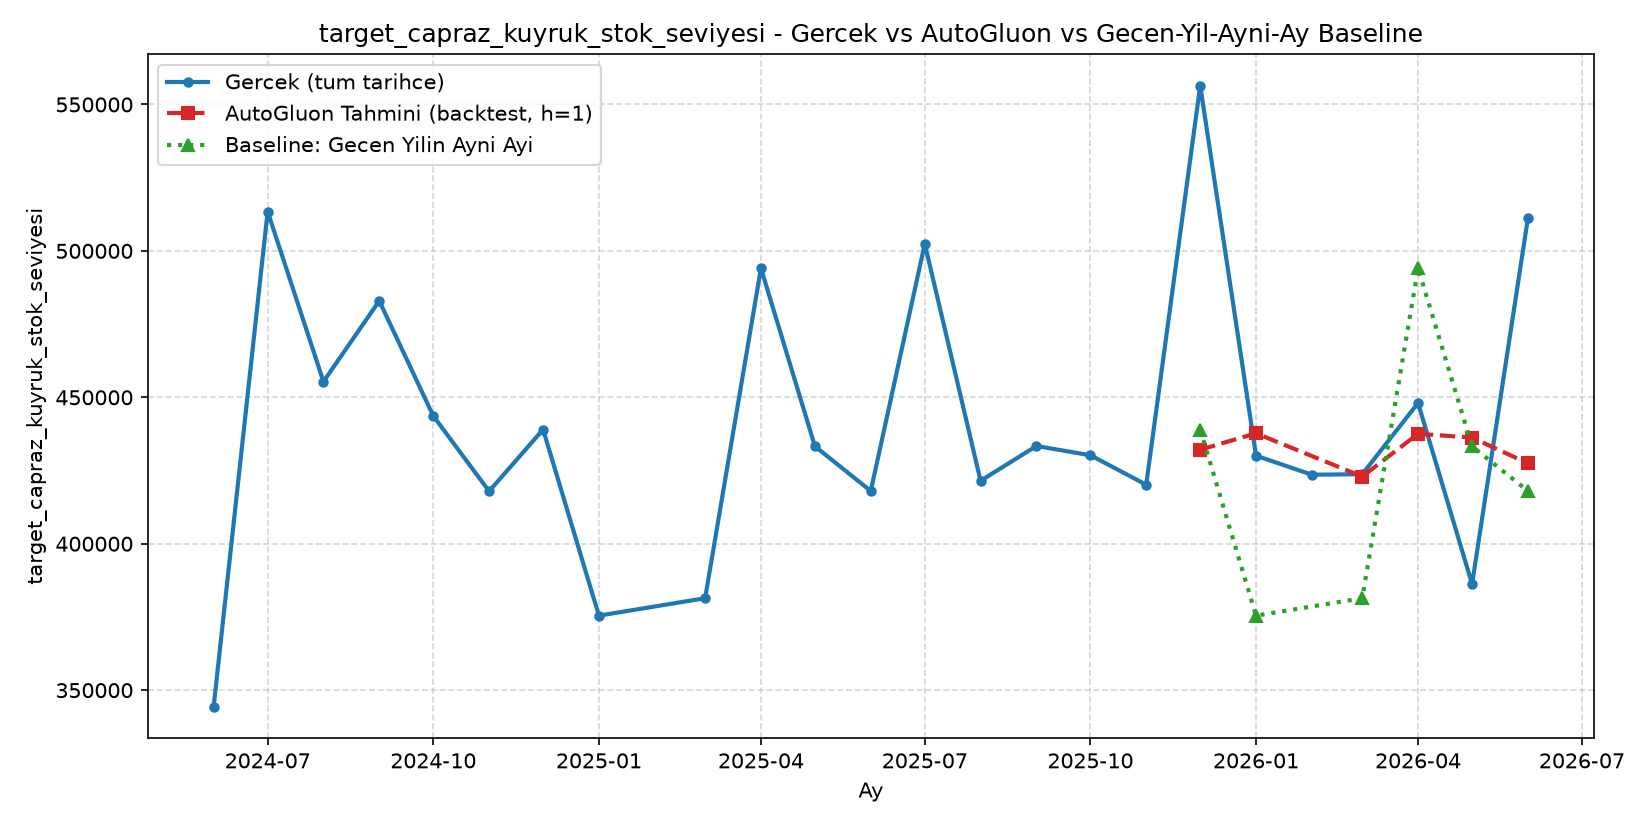

In [10]:
metrik_tablosu = pd.DataFrame(
    {
        "Model": sonuc["model_metrikleri"],
        "Baseline (t-12)": sonuc["baseline_metrikleri_gecen_yil_ayni_ay"],
    }
).T[["yon_dogrulugu", "mae", "rmse", "mase", "smape_pct", "bias", "n_test_ay"]]

display(metrik_tablosu)
display(backtest_df)
display(final_features)

grafik_yolu = OUT_DIR / "tahmin_grafigi.png"
if grafik_yolu.exists():
    display(Image(filename=str(grafik_yolu)))

## 11. Bilinen sınırlamalar

- **Model mutlak hatada baseline'ı belirgin biçimde geçiyor, yön doğruluğunda eşitler.** MAE
  46,177 vs 66,766, RMSE 64,733 vs 72,539, MASE 0.921 vs 1.332 (ikisi de `<1`'e ne kadar yakınsa
  o kadar mevsimsel naif'ten iyi; model burada gerçek mevsimsel oynaklığa daha yakın), sMAPE
  %9.92 vs %14.83 — dördünde de model daha düşük hatalı. Ama yön doğruluğunda ikisi de aynı
  oranda (5/6 = %83.3) tuttu; mutlak hatadaki üstünlük "gelecek ay çıkar mı düşer mi" sorusuna
  otomatik olarak yansımıyor. İkisi de negatif bias taşıyor (model −26,949, baseline −35,740) —
  yani her ikisi de stok seviyesini sistematik olarak hafif düşük tahmin ediyor, baseline daha
  belirgin biçimde.
- **AutoGluon'un `medium_quality` preset'i sabit random seed kullanmadığından ve backtest
  örneklemi küçük (n=6) olduğundan**, bu hedefte de yeniden çalıştırmalar arasında sonuçların
  (özellikle yön doğruluğunda) belirgin şekilde değişebildiği bu projede daha önce gözlemlenmiş
  bir bulgudur; tek bir çalıştırmadaki "kazanan" yorumu ihtiyatla okunmalı.
- Fold başına en iyi model üç farklı aileden geldi: `DirectTabular` (2/6), `WeightedEnsemble`
  (3/6), `Toto2` (1/6) — model seçiminin fold'lar arasında istikrarsız olması küçük örneklemin
  bir başka belirtisi.
- Örneklem yalnızca 28 ay (2024-01 → 2026-06) ve backtest ayları **ardışık değil** (2026-02
  seride 2025-02 iç boşluğu yüzünden aday listesinden düşüyor, bkz. Bölüm 5); tek bir
  yanlış/doğru yön tahmini, yön doğruluğunu ~%17 oynatıyor.
- Hedef, iki farklı ölçekteki serinin (aylık devir hacmi ve ilanda kalış süresi) çarpımı
  olduğundan, iki kaynaktan birindeki tek aylık bir anomali (ör. kısa bir ayda devir hacminin
  aniden sıçraması veya DOM'un aniden uzaması) stok seviyesini orantısız büyütebilir — 2025-12
  gözlemindeki sıçrama (gerçek 556,455 vs model tahmini 432,094, bkz. Bölüm 10 tablosu) buna bir
  örnek.
- Hedef, tasarım gereği bir **seviye** (stok adedi) ölçüsüdür, büyüme hızı değil — bkz. Bölüm 0
  başlık altındaki tasarım notu: büyüme-hızı versiyonu, zaten var olan iki targetin (`target_1ay_hiz`
  + `betam_dom_gun` log-farkı) cebirsel toplamına eşit çıktığından (log özdeşliği gereği, fark <
  1e-13) ayrı bir hedef olarak eklenmedi.